# HomeLens AI: NLP-Based Business Risk Intelligence for Home-Service Providers
## Final Course Project Code Submission

**Course:** CIS 509 — Analytics for Unstructured Data  
**Team ID:** HomeLensAI  
**Team members:** Rithik Roy Thati · Kanha Jodhpurkar · Sankalp Sharma Madgula · Dev Bhattacharyya

### Final business question
> Can natural-language processing identify, classify, and explain operational and reputational business-risk signals in Yelp reviews so home-service managers can prioritize corrective action?

### Final solution
This notebook builds an end-to-end decision-support pipeline that:

1. cleans and masks Yelp review text;
2. creates business-held-out train, validation, and test sets;
3. compares a lexicon baseline with TF–IDF Logistic Regression;
4. fine-tunes DistilBERT in Google Colab when a GPU is available;
5. extracts explainable complaint aspects with spaCy;
6. aggregates review-level signals into anonymized provider risk tiers; and
7. maps the leading complaint category to a management action.

**Responsible-use boundary:** “Business risk” means review-based operational and reputation signals. The system does not predict bankruptcy, prove misconduct, establish legal liability, or verify customer allegations.

## How this notebook maps to the final rubric

| Rubric category | Evidence in this notebook |
|---|---|
| **Business Problem Definition — 15%** | Clear Yelp-based business problem, stakeholders, operational decisions, and responsible-use limits. |
| **EDA — 10%** | Corpus filtering, missingness, duplicate audit, class balance, document length, service-category patterns, and topic discovery. |
| **Methodology — 25%** | NLTK text analysis, leakage masking, group-aware evaluation, TF–IDF, DistilBERT fine-tuning, spaCy `PhraseMatcher`, NMF topics, and threshold selection. |
| **Results & Business Insights — 25%** | Model comparison, error analysis, complaint-aspect lift, provider-level risk benchmarking, and management recommendations. |
| **Code Clarity & Quality — 15%** | Modular functions, fixed random seeds, explicit validation checks, no exposed tokens, and reusable inference functions. |

The separate presentation should communicate the most important results in approximately 12–15 minutes.

## Google Colab run instructions

For the **final submitted notebook**, run all cells with stored outputs.

1. Open this notebook in Google Colab.
2. Select **Runtime → Change runtime type → T4 GPU**.
3. Upload `HomeLens_Yelp_HomeServices.csv` to the Colab session or place it in Google Drive.
4. A Hugging Face token is **not required** to download the public DistilBERT checkpoint. Add an `HF_TOKEN` in Colab Secrets only when `PUSH_TO_HUB = True`.
5. Select **Runtime → Run all**.
6. Confirm that the final validation cell reports no business overlap and no missing model results.
7. Save/download the executed `.ipynb`. The final-code submission page asks for the Python notebook; it does not ask for an HTML export.

In [25]:
# Install advanced-model packages only in Google Colab.
# The core EDA and classical NLP sections use commonly available packages.
import importlib.util
import subprocess
import sys

IN_COLAB = importlib.util.find_spec("google.colab") is not None

required_packages = {
    "spacy": "spacy",
    "textblob": "textblob",
    "transformers": "transformers",
    "datasets": "datasets",
    "evaluate": "evaluate",
    "accelerate": "accelerate",
    "huggingface_hub": "huggingface_hub",
}
missing_packages = [
    package for module, package in required_packages.items()
    if importlib.util.find_spec(module) is None
]

if IN_COLAB and missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])
    print("Installed missing Colab packages:", missing_packages)
elif IN_COLAB:
    print("Required Colab packages are already available.")
else:
    print("Local execution detected; package installation skipped.")

Required Colab packages are already available.


In [26]:
from __future__ import annotations

from pathlib import Path
from collections import Counter
from typing import Any
import importlib.util
import json
import math
import os
import random
import re
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spacy
from IPython.display import display
from nltk import bigrams
from nltk.tokenize import RegexpTokenizer
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from spacy.matcher import PhraseMatcher
from textblob import TextBlob

warnings.filterwarnings("ignore")

RANDOM_SEED = 509
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

# Public checkpoint; no token is required for download.
MODEL_CHECKPOINT = "distilbert/distilbert-base-uncased"
MAX_LENGTH = 256
PUSH_TO_HUB = False
HF_REPOSITORY_ID = "homelens-ai-business-risk"  # Change only when uploading to your own account.

# GPU controls: DistilBERT runs automatically when a CUDA GPU is available.
try:
    import torch
    CUDA_AVAILABLE = torch.cuda.is_available()
except Exception:
    torch = None
    CUDA_AVAILABLE = False

RUN_TRANSFORMER = bool(IN_COLAB and CUDA_AVAILABLE)

print("IN_COLAB:", IN_COLAB)
print("CUDA_AVAILABLE:", CUDA_AVAILABLE)
print("RUN_TRANSFORMER:", RUN_TRANSFORMER)

IN_COLAB: True
CUDA_AVAILABLE: True
RUN_TRANSFORMER: True


## Optional secure Hugging Face authentication

Authentication is used only when the team chooses to upload the fine-tuned model. The token is read from Colab Secrets and is never printed or stored in the notebook.

In [27]:
HF_AUTHENTICATED = False

if PUSH_TO_HUB:
    if not IN_COLAB:
        raise RuntimeError("Model upload is configured for Google Colab.")
    from google.colab import userdata
    from huggingface_hub import login

    hf_token = userdata.get("HF_TOKEN")
    if not hf_token:
        raise ValueError("Add a Colab Secret named HF_TOKEN before enabling PUSH_TO_HUB.")
    login(token=hf_token, add_to_git_credential=False)
    HF_AUTHENTICATED = True
    del hf_token
    print("Hugging Face authentication completed securely.")
else:
    print("PUSH_TO_HUB is False; authentication is not required.")

PUSH_TO_HUB is False; authentication is not required.


# 1. Business problem and analytical objective

Home-service firms depend on online reputation, repeat customers, referrals, scheduling reliability, quote accuracy, and quality of work. Managers may receive thousands of reviews, making it difficult to identify recurring problems early.

The primary stakeholders are business owners, operations managers, quality-control teams, customer-experience leaders, franchise or regional managers, and safety/compliance personnel.

The analytical objectives are to:

- identify reviews that require management attention;
- explain whether the concern involves workmanship, communication, pricing, reliability, delays, professionalism, warranty response, or safety/property damage;
- compare simple and advanced NLP methods on businesses not seen during training; and
- aggregate review signals into a transparent, relative provider-risk benchmark.

# 2. Data source and analytical scope

The project uses a derived subset of the **Yelp Open Dataset**. The source business and review records were joined with `business_id`, restricted to Tucson, Arizona, and filtered to home-service categories. The final input file contains review text plus business metadata.

The review `text` column is the primary unstructured input. Star ratings provide a practical weak label for model development:

- **1–2 stars:** negative / management-attention signal (`label = 1`)
- **4–5 stars:** positive (`label = 0`)
- **3 stars:** mixed/neutral; excluded from primary binary training and retained for separate qualitative analysis

Because Yelp ratings are user-generated, they are imperfect labels rather than verified measures of business quality.

In [24]:
from pathlib import Path
import pandas as pd
import os

# ------------------------------------------------------------
# 1. Mount Google Drive at a clean location
# ------------------------------------------------------------
DRIVE_MOUNT = "/content/drive2"

if not Path(DRIVE_MOUNT, "MyDrive").exists():
    from google.colab import drive
    drive.mount(DRIVE_MOUNT)

# ------------------------------------------------------------
# 2. Possible filenames
# ------------------------------------------------------------
DATA_FILENAMES = [
    "HomeLens_Yelp_HomeServices.csv",
    "HomeLens_Yelp_HomeServices (1).csv",
    "HomeLens_Yelp_HomeServices(1).csv",
]

# ------------------------------------------------------------
# 3. Check the most likely locations first
# ------------------------------------------------------------
candidate_paths = []

for filename in DATA_FILENAMES:
    candidate_paths.extend([
        Path("/content") / filename,
        Path(DRIVE_MOUNT) / "MyDrive" / filename,
        Path(DRIVE_MOUNT) / "MyDrive" / "Colab Notebooks" / filename,
        Path("/kaggle/working") / filename,
        Path("/mnt/data") / filename,
        Path.cwd() / filename,
    ])

data_path = next(
    (path for path in candidate_paths if path.exists()),
    None
)

# ------------------------------------------------------------
# 4. If not found directly, search Google Drive recursively
# ------------------------------------------------------------
if data_path is None:
    drive_root = Path(DRIVE_MOUNT) / "MyDrive"

    if drive_root.exists():
        for filename in DATA_FILENAMES:
            matches = list(drive_root.rglob(filename))

            if matches:
                data_path = matches[0]
                break

# ------------------------------------------------------------
# 5. Stop with a clear error if the dataset is still missing
# ------------------------------------------------------------
if data_path is None:
    raise FileNotFoundError(
        "HomeLens Yelp CSV was not found.\n"
        "Expected it in Google Drive under My Drive/Colab Notebooks.\n"
        "Accepted filenames:\n"
        + "\n".join(DATA_FILENAMES)
    )

# ------------------------------------------------------------
# 6. Load the dataset
# ------------------------------------------------------------
raw_df = pd.read_csv(data_path)

# Convert date safely
if "date" in raw_df.columns:
    raw_df["date"] = pd.to_datetime(
        raw_df["date"],
        errors="coerce"
    )

# ------------------------------------------------------------
# 7. Verify the correct dataset was loaded
# ------------------------------------------------------------
print("=" * 70)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 70)
print("File:", data_path)
print("Shape:", raw_df.shape)
print("Rows:", f"{len(raw_df):,}")
print("Columns:", len(raw_df.columns))

print("\nColumn names:")
print(raw_df.columns.tolist())

print("\nPreview:")
display(raw_df.head(3))

Mounted at /content/drive2
DATASET LOADED SUCCESSFULLY
File: /content/drive2/MyDrive/Colab Notebooks/HomeLens_Yelp_HomeServices.csv
Shape: (23685, 17)
Rows: 23,685
Columns: 17

Column names:
['review_id', 'business_id', 'user_id', 'review_stars', 'sentiment_label', 'date', 'text', 'useful', 'funny', 'cool', 'name', 'city', 'state', 'postal_code', 'business_stars', 'business_review_count', 'categories']

Preview:


,review_id,business_id,user_id,review_stars,sentiment_label,date,text,useful,funny,cool,name,city,state,postal_code,business_stars,business_review_count,categories
0,dy6qZXvPbzPV16C5qRfvYA,1__KKHIK8WuO_3zaXx6PmA,3MYdpmHeNwC6FquRWi3YOg,3,neutral,2006-11-26 07:15:23,They have a lot of safes here. Small and large. I even saw a big safe deposit box with dozens of drawers for sale.,1,1,0,Roadrunner Lock & Safe,Tucson,AZ,"85,712.000",4.000,19,"Home Services, Safe Stores, Keys & Locksmiths, Shopping"
1,WXoYaUqq05u9qoOU8MCxjg,2tSWTVynoI7Sc_BhGHsO9Q,EZwtbQWyD6w-kXTPJqPpHQ,3,neutral,2007-02-22 12:57:28,"For the most part they are great. If they could just work on giving better customer service, like helping customer ...",1,0,0,The Home Depot,Tucson,AZ,"85,716.000",3.000,75,"Home & Garden, Shopping, Building Supplies, Appliances, Home Services, Hardware Stores, Nurseries & Gardening"
2,k4BEov4O7Ja6ZhFsA_5KwQ,wstNWbkW_sKzSBWj_bOf4A,Yp4xG6g0Hg9OliyovpTrqA,3,neutral,2007-04-25 04:11:41,This hotel is part of the extended stay america chain. As such the rooms have kitchenettes. The location of the hote...,4,0,0,Crossland Economy Studios - Tucson,Tucson,AZ,"85,714.000",2.000,13,"Event Planning & Services, Real Estate, Hotels, Home Services, Hotels & Travel, Apartments"


In [28]:
REQUIRED_COLUMNS = {
    "review_id", "business_id", "user_id", "review_stars", "date", "text",
    "name", "city", "state", "business_stars", "business_review_count", "categories"
}
missing_columns = REQUIRED_COLUMNS - set(raw_df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

if raw_df["review_id"].duplicated().any():
    raise ValueError("Duplicate review IDs were found in the candidate file.")

print("Required schema validated.")

Required schema validated.


## 2.1 Reproducible core-category filter

Yelp categories are multi-label. The candidate file includes broad `Home Services` matches that can capture adjacent retail, hotel, apartment, or automotive businesses. The following transparent filter keeps operationally relevant home-service providers and excludes obvious adjacent categories.

In [29]:
def parse_categories(value: Any) -> set[str]:
    return {item.strip() for item in str(value).split(",") if item.strip()}

CORE_CATEGORIES = {
    "Contractors", "General Contractors", "Plumbing",
    "Heating & Air Conditioning/HVAC", "Water Heater Installation/Repair",
    "Electricians", "Roofing", "Landscaping", "Landscape Architects",
    "Gardeners", "Tree Services", "Irrigation", "Lawn Services", "Painters",
    "Flooring", "Tiling", "Carpeting", "Carpet Installation", "Carpet Cleaning",
    "Home Cleaning", "Office Cleaning", "Window Washing", "Pressure Washers",
    "Pest Control", "Pool & Hot Tub Service", "Pool Cleaners", "Swimming Pools",
    "Damage Restoration", "Garage Door Services", "Door Sales/Installation",
    "Windows Installation", "Glass & Mirrors", "Keys & Locksmiths",
    "Security Systems", "Solar Installation", "Home Inspectors", "Handyman",
    "Fences & Gates", "Masonry/Concrete", "Septic Services",
    "Water Purification Services", "Appliances & Repair", "Junk Removal & Hauling",
    "Movers", "Packing Services", "Property Management", "Cabinetry",
    "Countertop Installation", "Kitchen & Bath", "Drywall Installation & Repair",
    "Stucco Services", "Refinishing Services", "Home Organization", "Interior Design",
    "Home Theatre Installation", "Air Duct Cleaning", "Hydro-jetting",
    "Grout Services", "Shades & Blinds", "Shutters",
    "Lighting Fixtures & Equipment", "Furniture Reupholstery", "Metal Fabricators"
}

category_sets = raw_df["categories"].apply(parse_categories)
core_mask = category_sets.apply(lambda values: bool(values & CORE_CATEGORIES))
core_mask &= ~category_sets.apply(lambda values: bool(values & {"Hotels", "Hotels & Travel"}))
core_mask &= ~category_sets.apply(
    lambda values: "Automotive" in values
    and not bool(values & {"Movers", "Junk Removal & Hauling", "Keys & Locksmiths"})
)
core_mask &= ~category_sets.apply(
    lambda values: "Apartments" in values and "Property Management" not in values
)

df = raw_df.loc[core_mask].copy()
df["category_set"] = category_sets.loc[core_mask]

selection_summary = pd.DataFrame({
    "stage": ["Candidate Yelp subset", "Core home-service subset", "Removed adjacent records"],
    "reviews": [len(raw_df), len(df), len(raw_df) - len(df)],
    "businesses": [
        raw_df["business_id"].nunique(),
        df["business_id"].nunique(),
        raw_df.loc[~core_mask, "business_id"].nunique(),
    ],
})
selection_summary["share_of_candidate"] = selection_summary["reviews"] / len(raw_df)
display(selection_summary)

,stage,reviews,businesses,share_of_candidate
0,Candidate Yelp subset,23685,1403,1.000
1,Core home-service subset,17943,1054,0.758
2,Removed adjacent records,5742,349,0.242


In [30]:
SERVICE_GROUPS = [
    ("Plumbing & Water", {
        "Plumbing", "Water Heater Installation/Repair", "Hydro-jetting",
        "Septic Services", "Water Purification Services"
    }),
    ("HVAC & Air Quality", {"Heating & Air Conditioning/HVAC", "Air Duct Cleaning"}),
    ("Cleaning & Restoration", {
        "Home Cleaning", "Office Cleaning", "Carpet Cleaning", "Window Washing",
        "Pressure Washers", "Damage Restoration", "Grout Services"
    }),
    ("Outdoor & Landscaping", {
        "Landscaping", "Landscape Architects", "Gardeners", "Tree Services",
        "Irrigation", "Lawn Services", "Pool & Hot Tub Service", "Pool Cleaners",
        "Swimming Pools", "Pest Control"
    }),
    ("Construction & Remodeling", {
        "Contractors", "General Contractors", "Roofing", "Painters", "Flooring",
        "Tiling", "Carpeting", "Carpet Installation", "Kitchen & Bath", "Cabinetry",
        "Countertop Installation", "Drywall Installation & Repair", "Stucco Services",
        "Masonry/Concrete", "Fences & Gates", "Interior Design",
        "Refinishing Services", "Metal Fabricators"
    }),
    ("Electrical, Solar & Security", {
        "Electricians", "Solar Installation", "Security Systems",
        "Lighting Fixtures & Equipment", "Home Theatre Installation"
    }),
    ("Repair & Installation", {
        "Appliances & Repair", "Garage Door Services", "Door Sales/Installation",
        "Windows Installation", "Glass & Mirrors", "Keys & Locksmiths", "Handyman",
        "Shades & Blinds", "Shutters", "Furniture Reupholstery", "Home Organization"
    }),
    ("Moving & Hauling", {"Movers", "Packing Services", "Junk Removal & Hauling"}),
    ("Property Management & Inspection", {"Property Management", "Home Inspectors"}),
]

def assign_service_group(category_set: set[str]) -> str:
    for group_name, group_categories in SERVICE_GROUPS:
        if category_set & group_categories:
            return group_name
    return "Other Core Home Services"

df["service_group"] = df["category_set"].apply(assign_service_group)
provider_map = {
    business_id: f"Provider_{number:04d}"
    for number, business_id in enumerate(sorted(df["business_id"].unique()), start=1)
}
df["provider_code"] = df["business_id"].map(provider_map)

print(f"Core reviews: {len(df):,}")
print(f"Core businesses: {df['business_id'].nunique():,}")
print(f"Unique reviewers: {df['user_id'].nunique():,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Market: {df['city'].mode().iat[0]}, {df['state'].mode().iat[0]}")

Core reviews: 17,943
Core businesses: 1,054
Unique reviewers: 12,384
Date range: 2006-11-26 to 2022-01-19
Market: Tucson, AZ


# 3. Final EDA summary

The final rubric gives EDA 10%, so this section focuses on decision-relevant checks rather than reproducing every Milestone 2 chart.

In [31]:
# Quality audit
normalized_text = (
    df["text"].astype(str).str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
)
quality_summary = pd.DataFrame({
    "quality_check": [
        "Missing review text", "Blank review text", "Missing review date",
        "Missing postal code", "Duplicate review IDs", "Exact normalized duplicate text"
    ],
    "count": [
        int(df["text"].isna().sum()),
        int((df["text"].astype(str).str.strip() == "").sum()),
        int(df["date"].isna().sum()),
        int(df["postal_code"].isna().sum()),
        int(df["review_id"].duplicated().sum()),
        int(normalized_text.duplicated().sum()),
    ],
})
quality_summary["percent"] = quality_summary["count"] / len(df)
display(quality_summary)

,quality_check,count,percent
0,Missing review text,0,0.000
1,Blank review text,0,0.000
2,Missing review date,0,0.000
3,Missing postal code,30,0.002
4,Duplicate review IDs,0,0.000
5,Exact normalized duplicate text,54,0.003


In [32]:
# NLTK tokenization and compact corpus statistics
word_tokenizer = RegexpTokenizer(r"[A-Za-z]+(?:'[A-Za-z]+)?")

def tokenize_words(text: str) -> list[str]:
    return [token.lower() for token in word_tokenizer.tokenize(str(text))]

df["word_count"] = df["text"].apply(lambda text: len(tokenize_words(text)))
all_tokens = [token for text in df["text"] for token in tokenize_words(text)]

corpus_summary = pd.DataFrame({
    "measure": [
        "Documents", "Businesses", "Total word tokens", "Raw vocabulary",
        "Median words per review", "Mean words per review"
    ],
    "value": [
        len(df), df["business_id"].nunique(), len(all_tokens), len(set(all_tokens)),
        int(df["word_count"].median()), round(df["word_count"].mean(), 1)
    ],
})
display(corpus_summary)

,measure,value
0,Documents,"17,943.000"
1,Businesses,"1,054.000"
2,Total word tokens,"2,069,734.000"
3,Raw vocabulary,"25,113.000"
4,Median words per review,83.000
5,Mean words per review,115.400


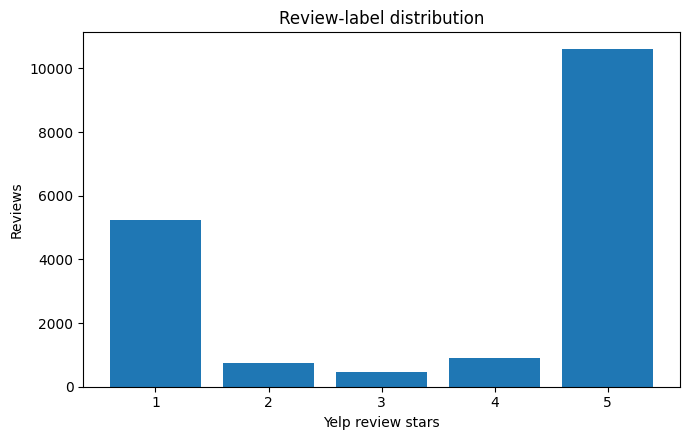

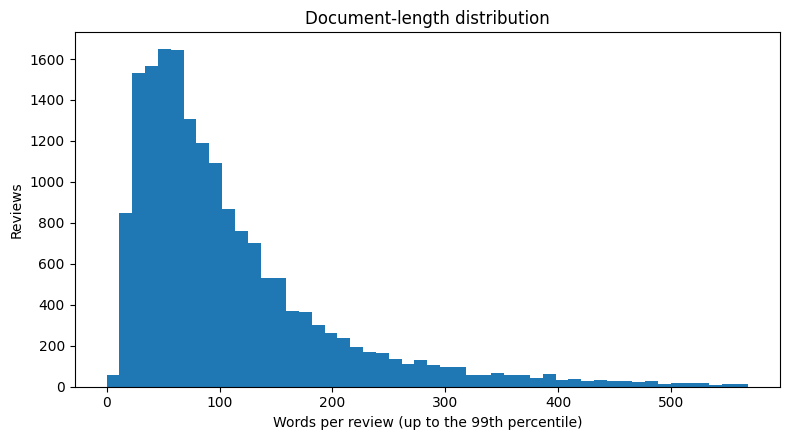

In [33]:
# Star balance and review length
star_counts = df["review_stars"].value_counts().sort_index()

plt.figure(figsize=(7, 4.5))
plt.bar(star_counts.index.astype(str), star_counts.values)
plt.xlabel("Yelp review stars")
plt.ylabel("Reviews")
plt.title("Review-label distribution")
plt.tight_layout()
plt.show()

upper_length = df["word_count"].quantile(0.99)
plt.figure(figsize=(8, 4.5))
plt.hist(df.loc[df["word_count"] <= upper_length, "word_count"], bins=50)
plt.xlabel("Words per review (up to the 99th percentile)")
plt.ylabel("Reviews")
plt.title("Document-length distribution")
plt.tight_layout()
plt.show()

,reviews,businesses,average_stars,negative_rate
service_group,,,,
Property Management & Inspection,1404,88,2.274,0.672
"Electrical, Solar & Security",1023,54,3.204,0.433
Moving & Hauling,1280,65,3.546,0.349
Plumbing & Water,2869,114,3.604,0.332
Repair & Installation,1564,97,3.623,0.332
Construction & Remodeling,3724,236,3.744,0.293
Outdoor & Landscaping,2978,205,3.811,0.287
HVAC & Air Quality,1383,80,3.915,0.258
Cleaning & Restoration,1718,115,4.049,0.224


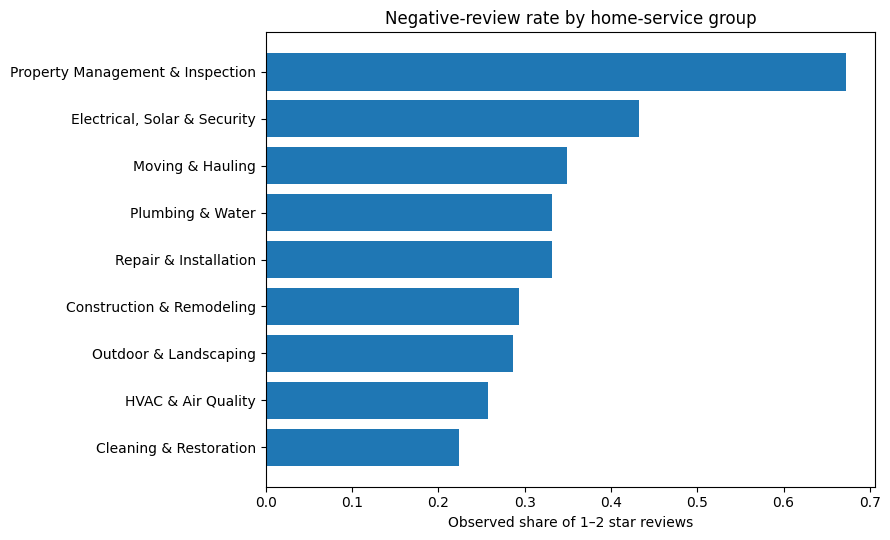

In [34]:
service_summary = (
    df.groupby("service_group")
      .agg(
          reviews=("review_id", "size"),
          businesses=("business_id", "nunique"),
          average_stars=("review_stars", "mean"),
          negative_rate=("review_stars", lambda values: float((values <= 2).mean())),
      )
      .sort_values("negative_rate", ascending=False)
)
display(service_summary)

plot_data = service_summary.sort_values("negative_rate")
plt.figure(figsize=(9, 5.5))
plt.barh(plot_data.index, plot_data["negative_rate"])
plt.xlabel("Observed share of 1–2 star reviews")
plt.title("Negative-review rate by home-service group")
plt.tight_layout()
plt.show()

### EDA interpretation

- The corpus is large enough for both classical NLP and transformer fine-tuning.
- Reviews are long enough to contain multi-sentence descriptions of service events, not only short sentiment statements.
- Ratings are strongly polarized, supporting a clear binary benchmark, while three-star reviews remain useful for mixed-sentiment error analysis.
- Service groups show materially different observed complaint rates; these are descriptive associations and must not be interpreted as causal or as proof of provider quality.

# 4. Privacy protection and target-leakage masking

The text can contain phone numbers, emails, URLs, dollar values, and explicit statements such as “one star.” Direct star phrases would leak the supervised target. PII and explicit rating phrases are masked before model training. Dollar values are also masked while retaining the semantic signal that pricing was discussed.

In [35]:
MASKING_RULES = [
    (r"(?:https?://|www\.)\S+", " URLTOKEN "),
    (r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b", " EMAILTOKEN "),
    (r"\b(?:\+?1[-.\s]?)?\(?\d{3}\)?[-.\s]\d{3}[-.\s]\d{4}\b", " PHONETOKEN "),
    (r"\$\s?\d[\d,]*(?:\.\d{2})?", " MONEYTOKEN "),
    (
        r"\b(?:zero|one|two|three|four|five|first|second|third|fourth|fifth|"
        r"[0-5](?:st|nd|rd|th)?)[- ]?star(?:s)?\b",
        " RATINGTOKEN ",
    ),
]

def mask_sensitive_and_leakage(text: str) -> str:
    cleaned = str(text)
    for pattern, replacement in MASKING_RULES:
        cleaned = re.sub(pattern, replacement, cleaned, flags=re.IGNORECASE)
    return re.sub(r"\s+", " ", cleaned).strip()

df["model_text"] = df["text"].apply(mask_sensitive_and_leakage)

mask_audit = []
for pattern, replacement in MASKING_RULES:
    matches = df["text"].str.contains(pattern, case=False, regex=True, na=False)
    mask_audit.append({"replacement": replacement.strip(), "reviews_matched": int(matches.sum()), "share": matches.mean()})

display(pd.DataFrame(mask_audit).sort_values("reviews_matched", ascending=False))

,replacement,reviews_matched,share
3,MONEYTOKEN,2248,0.125
4,RATINGTOKEN,1013,0.056
2,PHONETOKEN,49,0.003
0,URLTOKEN,43,0.002
1,EMAILTOKEN,14,0.001


# 5. Leakage-resistant train, validation, and test design

The same provider can receive many reviews with repeated names, staff references, service vocabulary, and writing patterns. A random review split would allow the same business to appear in both training and testing.

This notebook uses **stratified group splits**:

- each business appears in exactly one partition;
- the negative/positive class balance is kept as similar as possible;
- validation data select hyperparameters and thresholds;
- the untouched test set reports final performance.

In [36]:
model_df = df[df["review_stars"] != 3].copy()
model_df["normalized_model_text"] = (
    model_df["model_text"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
)
model_df = model_df.drop_duplicates(subset="normalized_model_text").reset_index(drop=True)
model_df["label"] = (model_df["review_stars"] <= 2).astype(int)  # 1 = negative/risk; 0 = positive

outer_split = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
train_validation_index, test_index = next(
    outer_split.split(model_df, model_df["label"], groups=model_df["business_id"])
)
train_validation_df = model_df.iloc[train_validation_index].reset_index(drop=True)
test_df = model_df.iloc[test_index].reset_index(drop=True)

inner_split = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_SEED + 1)
train_index, validation_index = next(
    inner_split.split(
        train_validation_df,
        train_validation_df["label"],
        groups=train_validation_df["business_id"],
    )
)
train_df = train_validation_df.iloc[train_index].reset_index(drop=True)
validation_df = train_validation_df.iloc[validation_index].reset_index(drop=True)

split_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "reviews": [len(train_df), len(validation_df), len(test_df)],
    "businesses": [
        train_df["business_id"].nunique(),
        validation_df["business_id"].nunique(),
        test_df["business_id"].nunique(),
    ],
    "negative_rate": [
        train_df["label"].mean(), validation_df["label"].mean(), test_df["label"].mean()
    ],
})
display(split_summary)

train_businesses = set(train_df["business_id"])
validation_businesses = set(validation_df["business_id"])
test_businesses = set(test_df["business_id"])

assert not (train_businesses & validation_businesses)
assert not (train_businesses & test_businesses)
assert not (validation_businesses & test_businesses)
print("Business overlap across all partitions: 0")

,split,reviews,businesses,negative_rate
0,Train,10411,630,0.355
1,Validation,3691,211,0.319
2,Test,3331,213,0.330


Business overlap across all partitions: 0


In [37]:
def classification_metrics(y_true: np.ndarray, prediction: np.ndarray, probability: np.ndarray) -> dict[str, float]:
    precision, recall, negative_f1, _ = precision_recall_fscore_support(
        y_true, prediction, labels=[1], average=None, zero_division=0
    )
    return {
        "accuracy": accuracy_score(y_true, prediction),
        "macro_f1": f1_score(y_true, prediction, average="macro"),
        "negative_precision": precision[0],
        "negative_recall": recall[0],
        "negative_f1": negative_f1[0],
        "average_precision": average_precision_score(y_true, probability),
        "roc_auc": roc_auc_score(y_true, probability),
    }


def select_business_threshold(
    y_true: np.ndarray,
    probability: np.ndarray,
    recall_floor: float = 0.90,
) -> tuple[float, pd.DataFrame]:
    """Select the highest-precision threshold that reaches the required negative recall."""
    rows = []
    for threshold in np.linspace(0.05, 0.95, 181):
        prediction = (probability >= threshold).astype(int)
        precision, recall, negative_f1, _ = precision_recall_fscore_support(
            y_true, prediction, labels=[1], average=None, zero_division=0
        )
        rows.append({
            "threshold": threshold,
            "negative_precision": precision[0],
            "negative_recall": recall[0],
            "negative_f1": negative_f1[0],
            "macro_f1": f1_score(y_true, prediction, average="macro"),
        })

    table = pd.DataFrame(rows)
    feasible = table[table["negative_recall"] >= recall_floor]
    if not feasible.empty:
        best = feasible.sort_values(
            ["negative_precision", "macro_f1", "threshold"],
            ascending=[False, False, True],
        ).iloc[0]
    else:
        best = table.sort_values(["macro_f1", "negative_f1"], ascending=False).iloc[0]
    return float(best["threshold"]), table


def result_row(model_name: str, metrics: dict[str, float], threshold: float) -> dict[str, Any]:
    return {"model": model_name, "operating_threshold": threshold, **metrics}

# 6. Baseline 1 — Lexicon sentiment

TextBlob is used as a simple lexicon-style benchmark. The validation set chooses a threshold that prioritizes at least 90% recall for negative reviews. This tests whether generic polarity alone is sufficient for long home-service narratives.

In [38]:
for split_df in [validation_df, test_df]:
    split_df["textblob_polarity"] = split_df["text"].astype(str).apply(
        lambda text: TextBlob(text).sentiment.polarity
    )
    split_df["textblob_risk_probability"] = np.clip(
        (1 - split_df["textblob_polarity"]) / 2, 0, 1
    )

textblob_threshold, textblob_threshold_table = select_business_threshold(
    validation_df["label"].to_numpy(),
    validation_df["textblob_risk_probability"].to_numpy(),
    recall_floor=0.90,
)
textblob_test_probability = test_df["textblob_risk_probability"].to_numpy()
textblob_test_prediction = (textblob_test_probability >= textblob_threshold).astype(int)
textblob_metrics = classification_metrics(
    test_df["label"].to_numpy(), textblob_test_prediction, textblob_test_probability
)

print("Selected TextBlob threshold:", round(textblob_threshold, 3))
display(pd.DataFrame([result_row("TextBlob", textblob_metrics, textblob_threshold)]))
print(classification_report(
    test_df["label"], textblob_test_prediction,
    target_names=["positive", "negative"], digits=3
))

Selected TextBlob threshold: 0.405


,model,operating_threshold,accuracy,macro_f1,negative_precision,negative_recall,negative_f1,average_precision,roc_auc
0,TextBlob,0.405,0.793,0.785,0.630,0.909,0.744,0.848,0.911


              precision    recall  f1-score   support

    positive      0.943     0.736     0.827      2231
    negative      0.630     0.909     0.744      1100

    accuracy                          0.793      3331
   macro avg      0.786     0.823     0.785      3331
weighted avg      0.839     0.793     0.800      3331



### Baseline interpretation

Generic polarity can identify strongly emotional complaints, but it misses contextual cases such as “the technician was friendly, but the repair failed again.” A domain-trained classifier is expected to improve both precision and recall.

# 7. Baseline 2 — TF–IDF with Logistic Regression

The classical supervised model uses leakage-masked unigrams and bigrams. Four regularization values are compared on the validation businesses. The selected model is then retrained on train + validation data and evaluated once on untouched test businesses.

In [39]:
TFIDF_CONFIG = {
    "lowercase": True,
    "strip_accents": "unicode",
    "stop_words": "english",
    "ngram_range": (1, 2),
    "min_df": 3,
    "max_df": 0.97,
    "max_features": 60_000,
    "sublinear_tf": True,
}

vectorizer_validation = TfidfVectorizer(**TFIDF_CONFIG)
X_train = vectorizer_validation.fit_transform(train_df["model_text"])
X_validation = vectorizer_validation.transform(validation_df["model_text"])

validation_rows = []
for c_value in [0.5, 1.0, 2.0, 4.0]:
    candidate_model = LogisticRegression(
        class_weight="balanced",
        max_iter=2_000,
        solver="liblinear",
        C=c_value,
        random_state=RANDOM_SEED,
    )
    candidate_model.fit(X_train, train_df["label"])
    validation_probability = candidate_model.predict_proba(X_validation)[:, 1]
    candidate_threshold, _ = select_business_threshold(
        validation_df["label"].to_numpy(), validation_probability, recall_floor=0.90
    )
    validation_prediction = (validation_probability >= candidate_threshold).astype(int)
    candidate_metrics = classification_metrics(
        validation_df["label"].to_numpy(), validation_prediction, validation_probability
    )
    validation_rows.append({
        "C": c_value,
        "threshold": candidate_threshold,
        **candidate_metrics,
    })

validation_results = pd.DataFrame(validation_rows).sort_values(
    ["macro_f1", "negative_f1"], ascending=False
)
display(validation_results)

best_c = float(validation_results.iloc[0]["C"])
tfidf_threshold = float(validation_results.iloc[0]["threshold"])
print("Selected C:", best_c)
print("Selected business threshold:", round(tfidf_threshold, 3))

,C,threshold,accuracy,macro_f1,negative_precision,negative_recall,negative_f1,average_precision,roc_auc
3,4.000,0.620,0.952,0.944,0.945,0.902,0.923,0.980,0.991
2,2.000,0.610,0.951,0.943,0.943,0.902,0.922,0.978,0.990
1,1.000,0.590,0.950,0.942,0.938,0.904,0.921,0.976,0.989
0,0.500,0.570,0.949,0.940,0.933,0.903,0.918,0.973,0.988


Selected C: 4.0
Selected business threshold: 0.62


In [40]:
# Final TF–IDF fit on train + validation; test remains untouched.
train_full_df = pd.concat([train_df, validation_df], ignore_index=True)

tfidf_vectorizer = TfidfVectorizer(**TFIDF_CONFIG)
X_train_full = tfidf_vectorizer.fit_transform(train_full_df["model_text"])
X_test = tfidf_vectorizer.transform(test_df["model_text"])

tfidf_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2_000,
    solver="liblinear",
    C=best_c,
    random_state=RANDOM_SEED,
)
tfidf_model.fit(X_train_full, train_full_df["label"])

tfidf_test_probability = tfidf_model.predict_proba(X_test)[:, 1]
tfidf_test_prediction = (tfidf_test_probability >= tfidf_threshold).astype(int)
tfidf_metrics = classification_metrics(
    test_df["label"].to_numpy(), tfidf_test_prediction, tfidf_test_probability
)

print("TF–IDF test results")
display(pd.DataFrame([result_row("TF–IDF Logistic Regression", tfidf_metrics, tfidf_threshold)]))
print(classification_report(
    test_df["label"], tfidf_test_prediction,
    target_names=["positive", "negative"], digits=3
))
print("Confusion matrix [actual rows, predicted columns]:")
display(pd.DataFrame(
    confusion_matrix(test_df["label"], tfidf_test_prediction),
    index=["Actual positive", "Actual negative"],
    columns=["Predicted positive", "Predicted negative"],
))

TF–IDF test results


,model,operating_threshold,accuracy,macro_f1,negative_precision,negative_recall,negative_f1,average_precision,roc_auc
0,TF–IDF Logistic Regression,0.620,0.957,0.951,0.950,0.917,0.933,0.984,0.991


              precision    recall  f1-score   support

    positive      0.960     0.976     0.968      2231
    negative      0.950     0.917     0.933      1100

    accuracy                          0.957      3331
   macro avg      0.955     0.947     0.951      3331
weighted avg      0.957     0.957     0.957      3331

Confusion matrix [actual rows, predicted columns]:


,Predicted positive,Predicted negative
Actual positive,2178,53
Actual negative,91,1009


In [41]:
# Interpretable terms learned by the classical model.
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
coefficients = tfidf_model.coef_[0]

negative_indices = np.argsort(coefficients)[-20:][::-1]
positive_indices = np.argsort(coefficients)[:20]

term_table = pd.DataFrame({
    "negative_signal_terms": feature_names[negative_indices],
    "negative_coefficient": coefficients[negative_indices],
    "positive_signal_terms": feature_names[positive_indices],
    "positive_coefficient": coefficients[positive_indices],
})
display(term_table)

,negative_signal_terms,negative_coefficient,positive_signal_terms,positive_coefficient
0,moneytoken,9.521,great,-11.827
1,told,9.136,professional,-9.906
2,rude,8.771,thank,-8.420
3,said,7.919,highly,-7.122
4,worst,7.775,best,-7.049
5,poor,6.824,friendly,-6.939
6,unprofessional,6.688,amazing,-6.887
7,left,6.228,excellent,-6.846
8,terrible,6.002,reasonable,-6.798
9,don,5.917,helpful,-6.766


In [42]:
# Anonymized test errors for business interpretation.
error_table = test_df[["provider_code", "review_stars", "model_text"]].copy()
error_table["actual_negative"] = test_df["label"].to_numpy()
error_table["predicted_negative"] = tfidf_test_prediction
error_table["negative_probability"] = tfidf_test_probability
error_table["error_type"] = np.select(
    [
        (error_table["actual_negative"] == 1) & (error_table["predicted_negative"] == 0),
        (error_table["actual_negative"] == 0) & (error_table["predicted_negative"] == 1),
    ],
    ["False negative", "False positive"],
    default="Correct",
)

error_examples = pd.concat([
    error_table[error_table["error_type"] == "False negative"]
        .sort_values("negative_probability").head(3),
    error_table[error_table["error_type"] == "False positive"]
        .sort_values("negative_probability", ascending=False).head(3),
])
error_examples["masked_excerpt"] = error_examples["model_text"].str.slice(0, 220)
display(error_examples[[
    "error_type", "provider_code", "review_stars", "negative_probability", "masked_excerpt"
]])

,error_type,provider_code,review_stars,negative_probability,masked_excerpt
1130,False negative,Provider_0422,1,0.031,"I hired Rogo's to put a concrete counter top and seating area in my back yard. They were polite, worked hard and it ..."
814,False negative,Provider_0313,1,0.032,"Brenda (she sits at the front desk) is not very helpful. In fact, she attempts to get one to purchase things not nee..."
2570,False negative,Provider_0317,1,0.056,"OTW Out. This was a place of transition, and I'm thrilled to transition out. Great Staff and Maintenance Professionals."
2335,False positive,Provider_0397,4,0.960,I have been a customer of Intelligent Design for over 5 years and until today have always been treated with professi...
1670,False positive,Provider_0859,4,0.941,Ok they have good prices and decent quality cabinets and countertops for the price. But a couple changes on my end r...
34,False positive,Provider_0228,4,0.916,"I'm going to keep this one brief (pun totally intended, come back to it), mainly because now that I have internet at..."


# 8. Advanced NLP — DistilBERT fine-tuning

DistilBERT is selected because it captures word order and context while requiring less compute than full BERT. Dynamic padding and a maximum length of 256 tokens reduce unnecessary computation. The same business-held-out partitions are used for a fair comparison with TF–IDF.

This section runs automatically on a Colab GPU. It intentionally skips on a CPU-only runtime rather than silently producing a partial or impractically slow training run.

In [44]:
transformer_available = False
transformer_metrics: dict[str, float] | None = None
transformer_validation_metrics: dict[str, float] | None = None
transformer_threshold: float | None = None
transformer_test_probability: np.ndarray | None = None
transformer_test_prediction: np.ndarray | None = None

trainer = None
tokenizer = None
model = None

if RUN_TRANSFORMER:
    import math
    import inspect
    import torch

    from datasets import Dataset
    from transformers import (
        AutoModelForSequenceClassification,
        AutoTokenizer,
        DataCollatorWithPadding,
        EarlyStoppingCallback,
        Trainer,
        TrainingArguments,
    )

    # ---------------------------------------------------------
    # Labels
    # ---------------------------------------------------------
    id2label = {
        0: "POSITIVE",
        1: "NEGATIVE_RISK",
    }

    label2id = {
        label: index
        for index, label in id2label.items()
    }

    # ---------------------------------------------------------
    # Tokenizer
    # ---------------------------------------------------------
    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_CHECKPOINT
    )

    # ---------------------------------------------------------
    # Convert pandas DataFrames to Hugging Face datasets
    # ---------------------------------------------------------
    def to_hf_dataset(frame: pd.DataFrame) -> Dataset:
        temp = (
            frame[["model_text", "label"]]
            .rename(columns={"model_text": "text"})
            .copy()
        )

        return Dataset.from_pandas(
            temp,
            preserve_index=False,
        )

    hf_train = to_hf_dataset(train_df)
    hf_validation = to_hf_dataset(validation_df)
    hf_test = to_hf_dataset(test_df)

    # ---------------------------------------------------------
    # Tokenization
    # ---------------------------------------------------------
    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=MAX_LENGTH,
        )

    tokenized_train = hf_train.map(
        tokenize_batch,
        batched=True,
    )

    tokenized_validation = hf_validation.map(
        tokenize_batch,
        batched=True,
    )

    tokenized_test = hf_test.map(
        tokenize_batch,
        batched=True,
    )

    data_collator = DataCollatorWithPadding(
        tokenizer=tokenizer
    )

    # ---------------------------------------------------------
    # Load DistilBERT classifier
    # ---------------------------------------------------------
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=2,
        id2label=id2label,
        label2id=label2id,
    )

    # ---------------------------------------------------------
    # Training configuration
    # ---------------------------------------------------------
    TRAIN_BATCH_SIZE = 16
    EVAL_BATCH_SIZE = 32
    NUM_EPOCHS = 3

    # Fix for transformers versions that do not support
    # warmup_ratio.
    steps_per_epoch = math.ceil(
        len(train_df) / TRAIN_BATCH_SIZE
    )

    total_training_steps = (
        steps_per_epoch * NUM_EPOCHS
    )

    warmup_steps = max(
        1,
        int(total_training_steps * 0.10)
    )

    print("Training reviews:", len(train_df))
    print("Validation reviews:", len(validation_df))
    print("Test reviews:", len(test_df))
    print("Warmup steps:", warmup_steps)
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        print(
            "GPU:",
            torch.cuda.get_device_name(0)
        )

    # ---------------------------------------------------------
    # Handle Hugging Face API differences automatically
    # ---------------------------------------------------------
    training_arg_names = inspect.signature(
        TrainingArguments.__init__
    ).parameters

    training_kwargs = {
        "output_dir":
            "/content/homelens_distilbert_checkpoints",

        "learning_rate":
            2e-5,

        "per_device_train_batch_size":
            TRAIN_BATCH_SIZE,

        "per_device_eval_batch_size":
            EVAL_BATCH_SIZE,

        "num_train_epochs":
            NUM_EPOCHS,

        "weight_decay":
            0.01,

        # Replaces warmup_ratio=0.10
        "warmup_steps":
            warmup_steps,

        "save_strategy":
            "epoch",

        "logging_strategy":
            "steps",

        "logging_steps":
            100,

        "load_best_model_at_end":
            True,

        "metric_for_best_model":
            "macro_f1",

        "greater_is_better":
            True,

        "save_total_limit":
            1,

        "fp16":
            torch.cuda.is_available(),

        "report_to":
            "none",

        "seed":
            RANDOM_SEED,

        "data_seed":
            RANDOM_SEED,

        "push_to_hub":
            PUSH_TO_HUB,
    }

    # Current vs older transformers versions
    if "eval_strategy" in training_arg_names:
        training_kwargs["eval_strategy"] = "epoch"

    elif "evaluation_strategy" in training_arg_names:
        training_kwargs[
            "evaluation_strategy"
        ] = "epoch"

    if (
        PUSH_TO_HUB
        and "hub_model_id" in training_arg_names
    ):
        training_kwargs[
            "hub_model_id"
        ] = HF_REPOSITORY_ID

    # Remove arguments unsupported by the installed version
    training_kwargs = {
        key: value
        for key, value in training_kwargs.items()
        if key in training_arg_names
    }

    training_args = TrainingArguments(
        **training_kwargs
    )

    # ---------------------------------------------------------
    # Metrics
    # ---------------------------------------------------------
    def transformer_compute_metrics(
        eval_prediction
    ):
        logits, labels = eval_prediction

        probability = (
            torch.softmax(
                torch.tensor(logits),
                dim=1,
            )
            .numpy()[:, 1]
        )

        prediction = (
            probability >= 0.50
        ).astype(int)

        return classification_metrics(
            labels,
            prediction,
            probability,
        )

    # ---------------------------------------------------------
    # Trainer compatibility
    # ---------------------------------------------------------
    trainer_arg_names = inspect.signature(
        Trainer.__init__
    ).parameters

    trainer_kwargs = {
        "model":
            model,

        "args":
            training_args,

        "train_dataset":
            tokenized_train,

        "eval_dataset":
            tokenized_validation,

        "data_collator":
            data_collator,

        "compute_metrics":
            transformer_compute_metrics,

        "callbacks": [
            EarlyStoppingCallback(
                early_stopping_patience=1
            )
        ],
    }

    if "processing_class" in trainer_arg_names:
        trainer_kwargs[
            "processing_class"
        ] = tokenizer

    elif "tokenizer" in trainer_arg_names:
        trainer_kwargs[
            "tokenizer"
        ] = tokenizer

    trainer = Trainer(
        **trainer_kwargs
    )

    # ---------------------------------------------------------
    # Fine-tune DistilBERT
    # ---------------------------------------------------------
    print(
        "\nStarting DistilBERT fine-tuning..."
    )

    training_output = trainer.train()

    transformer_available = True

    print(
        "\nDistilBERT fine-tuning completed successfully."
    )

else:
    print(
        "DistilBERT was not trained because "
        "RUN_TRANSFORMER is False."
    )

Map:   0%|          | 0/10411 [00:00<?, ? examples/s]

Map:   0%|          | 0/3691 [00:00<?, ? examples/s]

Map:   0%|          | 0/3331 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training reviews: 10411
Validation reviews: 3691
Test reviews: 3331
Warmup steps: 195
CUDA available: True
GPU: Tesla T4

Starting DistilBERT fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Negative Precision,Negative Recall,Negative F1,Average Precision,Roc Auc
1,0.097525,0.094829,0.974533,0.970932,0.946458,0.975382,0.960702,0.989596,0.995987
2,0.061432,0.104933,0.973720,0.969406,0.979592,0.937182,0.957918,0.991966,0.996806


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


DistilBERT fine-tuning completed successfully.


In [45]:
if transformer_available:
    validation_prediction_output = trainer.predict(tokenized_validation)
    validation_logits = validation_prediction_output.predictions
    validation_probability = torch.softmax(torch.tensor(validation_logits), dim=1).numpy()[:, 1]

    transformer_threshold, transformer_threshold_table = select_business_threshold(
        validation_df["label"].to_numpy(), validation_probability, recall_floor=0.90
    )
    transformer_validation_prediction = (
        validation_probability >= transformer_threshold
    ).astype(int)
    transformer_validation_metrics = classification_metrics(
        validation_df["label"].to_numpy(),
        transformer_validation_prediction,
        validation_probability,
    )

    test_prediction_output = trainer.predict(tokenized_test)
    test_logits = test_prediction_output.predictions
    transformer_test_probability = torch.softmax(torch.tensor(test_logits), dim=1).numpy()[:, 1]
    transformer_test_prediction = (
        transformer_test_probability >= transformer_threshold
    ).astype(int)
    transformer_metrics = classification_metrics(
        test_df["label"].to_numpy(),
        transformer_test_prediction,
        transformer_test_probability,
    )

    print("Selected DistilBERT threshold:", round(transformer_threshold, 3))
    display(pd.DataFrame([
        result_row("Fine-tuned DistilBERT", transformer_metrics, transformer_threshold)
    ]))
    print(classification_report(
        test_df["label"], transformer_test_prediction,
        target_names=["positive", "negative"], digits=3
    ))

    FINAL_MODEL_DIR = Path("/content/HomeLensAI_DistilBERT")
    trainer.save_model(FINAL_MODEL_DIR)
    tokenizer.save_pretrained(FINAL_MODEL_DIR)
    print("Saved fine-tuned model to:", FINAL_MODEL_DIR)

    if PUSH_TO_HUB:
        trainer.push_to_hub()
else:
    print("Transformer metrics are pending GPU execution.")

Selected DistilBERT threshold: 0.95


,model,operating_threshold,accuracy,macro_f1,negative_precision,negative_recall,negative_f1,average_precision,roc_auc
0,Fine-tuned DistilBERT,0.950,0.976,0.973,0.972,0.955,0.963,0.993,0.996


              precision    recall  f1-score   support

    positive      0.978     0.987     0.982      2231
    negative      0.972     0.955     0.963      1100

    accuracy                          0.976      3331
   macro avg      0.975     0.971     0.973      3331
weighted avg      0.976     0.976     0.976      3331



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned model to: /content/HomeLensAI_DistilBERT


# 9. Final model comparison

Accuracy is reported for familiarity, but model selection emphasizes **macro F1**, **negative recall**, **negative precision**, **negative F1**, and **Average Precision**. The operating threshold is selected on validation businesses, not on test results.

,model,operating_threshold,accuracy,macro_f1,negative_precision,negative_recall,negative_f1,average_precision,roc_auc
2,Fine-tuned DistilBERT,0.950,0.976,0.973,0.972,0.955,0.963,0.993,0.996
1,TF–IDF Logistic Regression,0.620,0.957,0.951,0.950,0.917,0.933,0.984,0.991
0,TextBlob,0.405,0.793,0.785,0.630,0.909,0.744,0.848,0.911


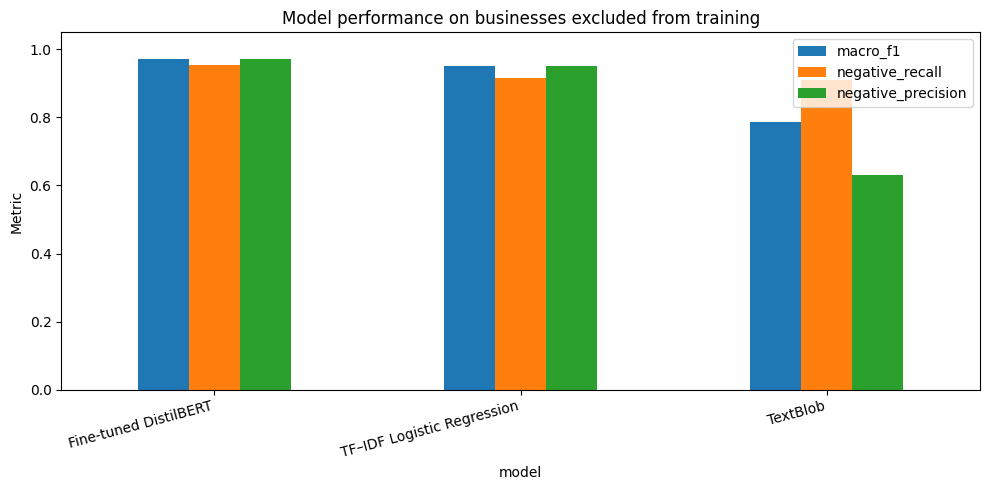

In [46]:
comparison_rows = [
    result_row("TextBlob", textblob_metrics, textblob_threshold),
    result_row("TF–IDF Logistic Regression", tfidf_metrics, tfidf_threshold),
]
if transformer_metrics is not None and transformer_threshold is not None:
    comparison_rows.append(
        result_row("Fine-tuned DistilBERT", transformer_metrics, transformer_threshold)
    )

model_comparison = pd.DataFrame(comparison_rows).sort_values("macro_f1", ascending=False)
display(model_comparison)

plot_data = model_comparison.set_index("model")[["macro_f1", "negative_recall", "negative_precision"]]
plot_data.plot(kind="bar", figsize=(10, 5))
plt.ylim(0, 1.05)
plt.ylabel("Metric")
plt.title("Model performance on businesses excluded from training")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [47]:
# Select the deployment model by validation performance, not by test performance.
tfidf_validation_macro_f1 = float(validation_results.iloc[0]["macro_f1"])

if (
    transformer_validation_metrics is not None
    and transformer_validation_metrics["macro_f1"] >= tfidf_validation_macro_f1
):
    best_model_name = "Fine-tuned DistilBERT"
else:
    best_model_name = "TF–IDF Logistic Regression"

print("TF–IDF validation macro F1:", round(tfidf_validation_macro_f1, 3))
if transformer_validation_metrics is not None:
    print(
        "DistilBERT validation macro F1:",
        round(transformer_validation_metrics["macro_f1"], 3),
    )
print("Deployment model selected from validation results:", best_model_name)

TF–IDF validation macro F1: 0.944
DistilBERT validation macro F1: 0.97
Deployment model selected from validation results: Fine-tuned DistilBERT


# 10. Explainable business-risk aspect extraction with spaCy

The sentiment model answers **whether** a review needs attention. The spaCy layer answers **why** by matching domain-specific complaint phrases. `PhraseMatcher` is appropriate for an interpretable, finite terminology list and can later bootstrap manually labeled training data.

In [48]:
RISK_PHRASES = {
    "Workmanship": [
        "poor quality", "bad job", "terrible job", "sloppy work", "unfinished work",
        "not finished", "installed incorrectly", "incorrect installation", "repair failed",
        "did not fix", "didn't fix", "still leaking", "stopped working", "made it worse",
        "broke again", "poor workmanship", "damaged the", "damaged my"
    ],
    "Reliability / No-show": [
        "no show", "never showed", "did not show", "didn't show", "never came",
        "did not come", "didn't come", "missed appointment", "cancelled appointment",
        "canceled appointment", "failed to arrive"
    ],
    "Timeliness": [
        "arrived late", "showed up late", "hours late", "days late", "project delayed",
        "missed deadline", "took weeks", "took months", "long wait", "still waiting",
        "slow service"
    ],
    "Pricing / Billing": [
        "overcharged", "charged more", "hidden fee", "hidden fees", "unexpected charge",
        "extra charge", "price changed", "estimate changed", "bait and switch",
        "too expensive", "way too expensive", "rip off", "ripped off"
    ],
    "Communication": [
        "never called back", "did not call back", "didn't call back", "no response",
        "never responded", "did not respond", "didn't respond", "stopped responding",
        "poor communication", "no communication", "would not return my call",
        "wouldn't return my call"
    ],
    "Professionalism / Trust": [
        "very rude", "rude staff", "unprofessional", "dishonest", "lied to me",
        "misleading", "scam", "fraud", "disrespectful", "aggressive behavior"
    ],
    "Safety / Property Damage": [
        "unsafe", "dangerous", "fire hazard", "electrical hazard", "gas leak",
        "water damage", "flooded my", "damaged my property", "mold problem", "safety issue"
    ],
    "Warranty / Follow-up": [
        "warranty not honored", "would not honor", "refused to fix", "would not fix",
        "wouldn't fix", "follow up repair", "follow-up repair", "return visit",
        "under warranty", "warranty claim"
    ],
}

nlp_matcher = spacy.blank("en")
nlp_matcher.add_pipe("sentencizer")
phrase_matcher = PhraseMatcher(nlp_matcher.vocab, attr="LOWER")

for aspect, phrases in RISK_PHRASES.items():
    phrase_matcher.add(aspect, [nlp_matcher.make_doc(phrase) for phrase in phrases])


def aspect_column(aspect: str) -> str:
    return "aspect_" + re.sub(r"\W+", "_", aspect.lower()).strip("_")

aspect_columns = [aspect_column(aspect) for aspect in RISK_PHRASES]
for column in aspect_columns:
    df[column] = False

for row_index, document in zip(
    df.index,
    nlp_matcher.pipe(df["text"].astype(str), batch_size=256),
):
    matched_aspects = {
        nlp_matcher.vocab.strings[match_id]
        for match_id, _, _ in phrase_matcher(document)
    }
    for aspect in matched_aspects:
        df.at[row_index, aspect_column(aspect)] = True

corpus_negative_rate = float((df["review_stars"] <= 2).mean())
aspect_rows = []
for aspect in RISK_PHRASES:
    column = aspect_column(aspect)
    mentioned = df[column]
    reviews_with_signal = int(mentioned.sum())
    negative_mentions = int((mentioned & (df["review_stars"] <= 2)).sum())
    negative_rate = negative_mentions / reviews_with_signal if reviews_with_signal else np.nan
    aspect_rows.append({
        "aspect": aspect,
        "reviews_with_signal": reviews_with_signal,
        "share_of_corpus": reviews_with_signal / len(df),
        "negative_reviews_with_signal": negative_mentions,
        "negative_rate_when_mentioned": negative_rate,
        "lift_vs_corpus_negative_rate": negative_rate / corpus_negative_rate,
    })

aspect_summary = pd.DataFrame(aspect_rows).sort_values(
    "negative_rate_when_mentioned", ascending=False
)
display(aspect_summary)

,aspect,reviews_with_signal,share_of_corpus,negative_reviews_with_signal,negative_rate_when_mentioned,lift_vs_corpus_negative_rate
5,Professionalism / Trust,806,0.045,765,0.949,2.841
4,Communication,245,0.014,214,0.873,2.615
1,Reliability / No-show,378,0.021,324,0.857,2.566
2,Timeliness,158,0.009,127,0.804,2.406
7,Warranty / Follow-up,100,0.006,68,0.680,2.036
3,Pricing / Billing,276,0.015,181,0.656,1.963
0,Workmanship,281,0.016,181,0.644,1.928
6,Safety / Property Damage,136,0.008,85,0.625,1.871


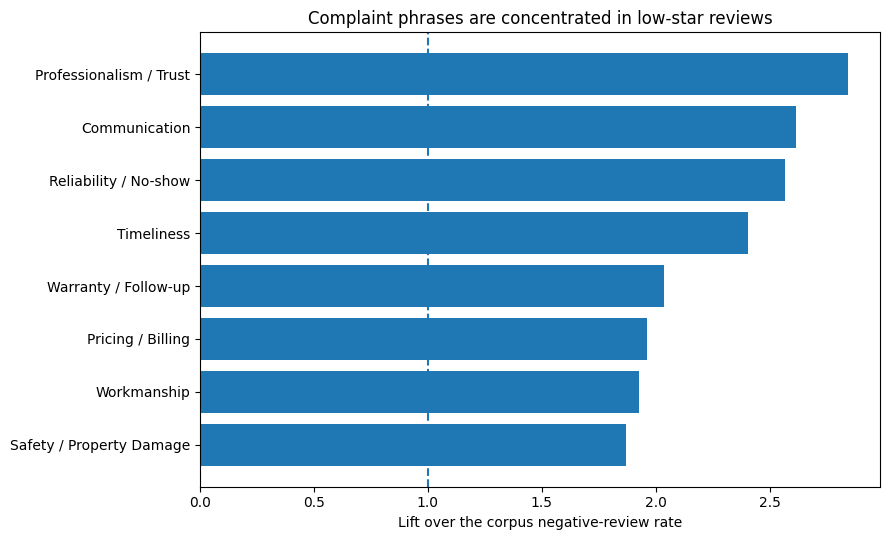

In [49]:
plot_data = aspect_summary.sort_values("lift_vs_corpus_negative_rate")
plt.figure(figsize=(9, 5.5))
plt.barh(plot_data["aspect"], plot_data["lift_vs_corpus_negative_rate"])
plt.axvline(1.0, linestyle="--")
plt.xlabel("Lift over the corpus negative-review rate")
plt.title("Complaint phrases are concentrated in low-star reviews")
plt.tight_layout()
plt.show()

# 11. Unsupervised negative-review topic discovery

NMF topic modeling complements the predefined spaCy dictionary by surfacing recurring language without requiring aspect labels. Topics are interpreted cautiously as language clusters, not objective facts.

In [50]:
negative_reviews = df[df["review_stars"] <= 2].copy()

topic_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    stop_words="english",
    ngram_range=(1, 2),
    min_df=8,
    max_df=0.90,
    max_features=12_000,
    sublinear_tf=True,
)
negative_tfidf = topic_vectorizer.fit_transform(negative_reviews["model_text"])

n_topics = 6
topic_model = NMF(
    n_components=n_topics,
    init="nndsvda",
    random_state=RANDOM_SEED,
    max_iter=500,
)
topic_weights = topic_model.fit_transform(negative_tfidf)
topic_terms = np.array(topic_vectorizer.get_feature_names_out())

interpretive_labels = [
    "Work, cleaning, and moving outcomes",
    "Property management and lease disputes",
    "Scheduling, appointments, and follow-up",
    "Warranty, equipment, and repair failure",
    "Customer service and professionalism",
    "Pricing, estimates, and billing",
]

topic_rows = []
for topic_number, component in enumerate(topic_model.components_, start=1):
    top_indices = component.argsort()[-12:][::-1]
    topic_rows.append({
        "topic": topic_number,
        "interpretive_label": interpretive_labels[topic_number - 1],
        "top_terms": ", ".join(topic_terms[top_indices]),
    })

topic_table = pd.DataFrame(topic_rows)
negative_reviews["dominant_topic"] = topic_weights.argmax(axis=1) + 1
topic_counts = negative_reviews["dominant_topic"].value_counts().sort_index()
topic_table["negative_reviews"] = topic_table["topic"].map(topic_counts).fillna(0).astype(int)
display(topic_table)

,topic,interpretive_label,top_terms,negative_reviews
0,1,"Work, cleaning, and moving outcomes","just, like, don, didn, job, did, work, know, good, store, time, want",1443
1,2,Property management and lease disputes,"service, customer, customer service, horrible, poor, terrible, worst, rude, worst customer, horrible customer, compa...",778
2,3,"Scheduling, appointments, and follow-up","called, appointment, day, time, told, phone, said, showed, scheduled, days, week, later",1097
3,4,"Warranty, equipment, and repair failure","moneytoken, charged, charge, charged moneytoken, cost, price, estimate, fee, moneytoken moneytoken, quoted, told, quote",732
4,5,Customer service and professionalism,"warranty, unit, company, home, fix, repair, ac, new, water, home warranty, problem, air",984
5,6,"Pricing, estimates, and billing","property, rent, management, company, lease, deposit, property management, management company, moved, worst, rental, ...",960


# 12. Provider-level business-risk intelligence

Review-level model scores are aggregated only for providers with at least 20 reviews. Provider names are anonymized. The risk score is a **relative benchmark within this historical Tucson corpus**, not an absolute probability of financial failure.

The score combines percentile ranks of:

- mean model-estimated review risk (50%);
- recent model-estimated review risk (30%); and
- high-severity aspect rate for workmanship, safety/property damage, or warranty/follow-up (20%).

Relative tiers are assigned as Stable, Watch, Elevated, and High concern.

In [51]:
# Produce a risk probability for every core review using the strongest completed model.
# DistilBERT is used after GPU execution when it beats the TF–IDF test macro F1; otherwise TF–IDF is used.
if best_model_name == "Fine-tuned DistilBERT" and transformer_available:
    all_hf = Dataset.from_pandas(
        df[["model_text"]].rename(columns={"model_text": "text"}), preserve_index=False
    )
    all_tokenized = all_hf.map(tokenize_batch, batched=True)
    all_output = trainer.predict(all_tokenized)
    df["risk_probability"] = torch.softmax(
        torch.tensor(all_output.predictions), dim=1
    ).numpy()[:, 1]
else:
    all_tfidf = tfidf_vectorizer.transform(df["model_text"])
    df["risk_probability"] = tfidf_model.predict_proba(all_tfidf)[:, 1]

df["observed_negative"] = (df["review_stars"] <= 2).astype(int)
df["review_year"] = df["date"].dt.year

high_severity_columns = [
    aspect_column("Workmanship"),
    aspect_column("Safety / Property Damage"),
    aspect_column("Warranty / Follow-up"),
]
df["high_severity_signal"] = df[high_severity_columns].any(axis=1).astype(int)

# Most frequent detected aspect for each provider.
aspect_counts_by_business = df.groupby("business_id")[aspect_columns].sum()
max_aspect_column = aspect_counts_by_business.idxmax(axis=1)
max_aspect_count = aspect_counts_by_business.max(axis=1)
column_to_label = {aspect_column(aspect): aspect for aspect in RISK_PHRASES}
provider_top_aspect = max_aspect_column.map(column_to_label)
provider_top_aspect[max_aspect_count == 0] = "No dictionary match"

Map:   0%|          | 0/17943 [00:00<?, ? examples/s]

In [52]:
provider_rows = []
recent_start = pd.Timestamp("2021-01-01")
previous_start = pd.Timestamp("2020-01-01")
previous_end = pd.Timestamp("2020-12-31 23:59:59")

for business_id, group in df.groupby("business_id"):
    if len(group) < 20:
        continue
    recent = group[group["date"] >= recent_start]
    previous = group[(group["date"] >= previous_start) & (group["date"] <= previous_end)]

    provider_rows.append({
        "provider_code": group["provider_code"].iloc[0],
        "service_group": group["service_group"].iloc[0],
        "reviews": len(group),
        "observed_negative_rate": group["observed_negative"].mean(),
        "mean_risk_probability": group["risk_probability"].mean(),
        "recent_reviews": len(recent),
        "recent_risk_probability": (
            recent["risk_probability"].mean() if len(recent) else np.nan
        ),
        "previous_reviews": len(previous),
        "previous_risk_probability": (
            previous["risk_probability"].mean() if len(previous) else np.nan
        ),
        "trend_delta": (
            recent["risk_probability"].mean() - previous["risk_probability"].mean()
            if len(recent) >= 3 and len(previous) >= 3 else np.nan
        ),
        "high_severity_rate": group["high_severity_signal"].mean(),
        "top_aspect": provider_top_aspect.get(business_id, "No dictionary match"),
        "latest_review": group["date"].max(),
    })

provider_risk = pd.DataFrame(provider_rows)
provider_risk["recent_risk_probability"] = provider_risk["recent_risk_probability"].fillna(
    provider_risk["mean_risk_probability"]
)

for column in ["mean_risk_probability", "recent_risk_probability", "high_severity_rate"]:
    provider_risk[f"{column}_percentile"] = provider_risk[column].rank(pct=True, method="average")

provider_risk["risk_score"] = 100 * (
    0.50 * provider_risk["mean_risk_probability_percentile"]
    + 0.30 * provider_risk["recent_risk_probability_percentile"]
    + 0.20 * provider_risk["high_severity_rate_percentile"]
)
provider_risk["risk_tier"] = pd.cut(
    provider_risk["risk_score"],
    bins=[-np.inf, 50, 75, 90, np.inf],
    labels=["Stable", "Watch", "Elevated", "High concern"],
)

display(provider_risk["risk_tier"].value_counts().sort_index().rename("providers"))

,providers
risk_tier,
Stable,123
Watch,78
Elevated,45
High concern,8


In [53]:
RECOMMENDATIONS = {
    "Workmanship": "Audit repeat jobs, callbacks, and post-service quality checks.",
    "Reliability / No-show": "Review scheduling, dispatch, and appointment-confirmation controls.",
    "Timeliness": "Investigate cycle-time bottlenecks and customer delay notifications.",
    "Pricing / Billing": "Review estimate accuracy, change-order approvals, and fee disclosure.",
    "Communication": "Strengthen callback ownership, status updates, and escalation procedures.",
    "Professionalism / Trust": "Review conduct complaints and reinforce customer-service standards.",
    "Safety / Property Damage": "Escalate for human review and investigate the reported safety/property-damage signal.",
    "Warranty / Follow-up": "Audit warranty response times, repeat repairs, and closure tracking.",
    "No dictionary match": "Perform manual review and expand the domain phrase dictionary.",
}
provider_risk["recommended_action"] = provider_risk["top_aspect"].map(RECOMMENDATIONS)

provider_dashboard = (
    provider_risk.sort_values("risk_score", ascending=False)
    [[
        "provider_code", "service_group", "reviews", "observed_negative_rate",
        "mean_risk_probability", "recent_risk_probability", "trend_delta",
        "high_severity_rate", "top_aspect", "risk_score", "risk_tier",
        "recommended_action"
    ]]
)
display(provider_dashboard.head(15))

,provider_code,service_group,reviews,observed_negative_rate,mean_risk_probability,recent_risk_probability,trend_delta,high_severity_rate,top_aspect,risk_score,risk_tier,recommended_action
57,Provider_0235,Cleaning & Restoration,25,1.000,0.997,0.997,NaN,0.120,Professionalism / Trust,98.307,High concern,Review conduct complaints and reinforce customer-service standards.
104,Provider_0442,"Electrical, Solar & Security",25,0.920,0.916,0.997,NaN,0.080,Workmanship,96.614,High concern,"Audit repeat jobs, callbacks, and post-service quality checks."
235,Provider_0979,Property Management & Inspection,29,0.862,0.906,0.997,NaN,0.069,Professionalism / Trust,96.496,High concern,Review conduct complaints and reinforce customer-service standards.
129,Provider_0545,Repair & Installation,95,0.832,0.819,0.997,0.111,0.116,Reliability / No-show,95.118,High concern,"Review scheduling, dispatch, and appointment-confirmation controls."
89,Provider_0384,Plumbing & Water,26,0.769,0.806,0.997,0.001,0.077,Professionalism / Trust,94.173,High concern,Review conduct complaints and reinforce customer-service standards.
216,Provider_0907,Property Management & Inspection,55,0.855,0.870,0.990,NaN,0.055,Professionalism / Trust,92.126,High concern,Review conduct complaints and reinforce customer-service standards.
8,Provider_0032,Plumbing & Water,20,0.800,0.797,0.997,NaN,0.050,Professionalism / Trust,90.433,High concern,Review conduct complaints and reinforce customer-service standards.
195,Provider_0816,Property Management & Inspection,30,0.867,0.864,0.998,NaN,0.033,Professionalism / Trust,90.394,High concern,Review conduct complaints and reinforce customer-service standards.
165,Provider_0697,"Electrical, Solar & Security",45,0.911,0.939,0.997,-0.000,0.022,Professionalism / Trust,88.661,Elevated,Review conduct complaints and reinforce customer-service standards.
118,Provider_0496,Property Management & Inspection,59,0.881,0.880,0.997,0.000,0.017,Professionalism / Trust,88.465,Elevated,Review conduct complaints and reinforce customer-service standards.


,eligible_businesses,median_risk_score,high_concern_providers,median_recent_risk
service_group,,,,
Property Management & Inspection,23,80.000,3,0.869
Repair & Installation,19,58.898,1,0.399
Plumbing & Water,47,58.071,2,0.421
"Electrical, Solar & Security",18,50.217,1,0.499
HVAC & Air Quality,16,49.843,0,0.233
Outdoor & Landscaping,38,45.709,0,0.269
Construction & Remodeling,49,45.315,0,0.285
Moving & Hauling,20,41.909,0,0.238
Cleaning & Restoration,24,41.713,1,0.413


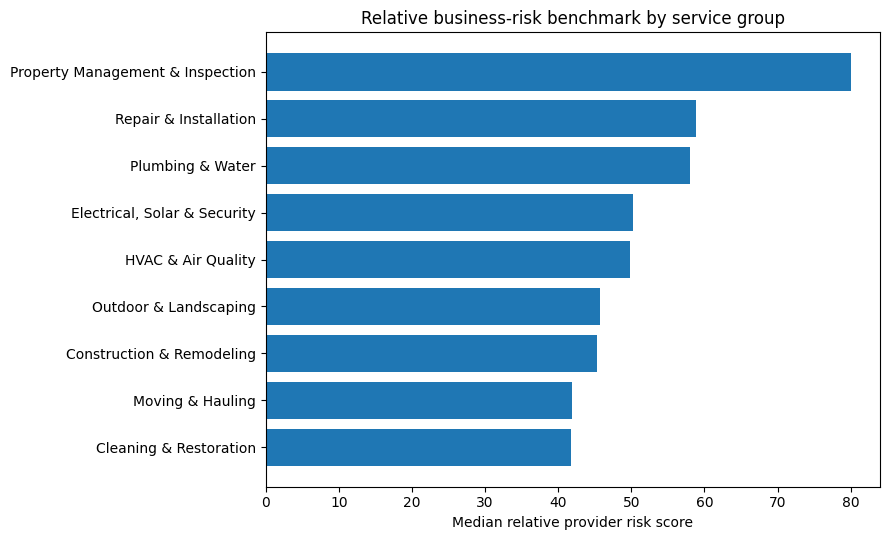

In [54]:
service_risk_summary = (
    provider_risk.groupby("service_group")
    .agg(
        eligible_businesses=("provider_code", "size"),
        median_risk_score=("risk_score", "median"),
        high_concern_providers=("risk_tier", lambda values: int((values == "High concern").sum())),
        median_recent_risk=("recent_risk_probability", "median"),
    )
    .sort_values("median_risk_score", ascending=False)
)
display(service_risk_summary)

plot_data = service_risk_summary.sort_values("median_risk_score")
plt.figure(figsize=(9, 5.5))
plt.barh(plot_data.index, plot_data["median_risk_score"])
plt.xlabel("Median relative provider risk score")
plt.title("Relative business-risk benchmark by service group")
plt.tight_layout()
plt.show()

# 13. Reusable review-level decision-support function

The function below combines the final classifier with spaCy complaint-aspect matching. It returns a risk probability, an operating decision, detected aspects, and a recommended management action. The example inputs are synthetic and contain no real provider names.

In [55]:
def extract_aspects(text: str) -> list[str]:
    document = nlp_matcher(str(text))
    return sorted({
        nlp_matcher.vocab.strings[match_id]
        for match_id, _, _ in phrase_matcher(document)
    })


def tfidf_risk_probability(text: str) -> float:
    masked = mask_sensitive_and_leakage(text)
    matrix = tfidf_vectorizer.transform([masked])
    return float(tfidf_model.predict_proba(matrix)[0, 1])


def transformer_risk_probability(text: str) -> float:
    if not transformer_available or tokenizer is None or trainer is None:
        raise RuntimeError("DistilBERT has not been trained in this runtime.")
    inputs = tokenizer(
        mask_sensitive_and_leakage(text),
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(trainer.model.device)
    trainer.model.eval()
    with torch.no_grad():
        logits = trainer.model(**inputs).logits
    return float(torch.softmax(logits, dim=1)[0, 1].cpu())


def analyze_review(text: str) -> dict[str, Any]:
    aspects = extract_aspects(text)

    if best_model_name == "Fine-tuned DistilBERT" and transformer_available:
        probability = transformer_risk_probability(text)
        threshold = float(transformer_threshold)
        model_used = "Fine-tuned DistilBERT"
    else:
        probability = tfidf_risk_probability(text)
        threshold = float(tfidf_threshold)
        model_used = "TF–IDF Logistic Regression"

    primary_aspect = aspects[0] if aspects else "No dictionary match"
    return {
        "model": model_used,
        "negative_risk_probability": round(probability, 4),
        "operating_threshold": round(threshold, 4),
        "management_attention": bool(probability >= threshold),
        "detected_aspects": aspects,
        "recommended_action": RECOMMENDATIONS[primary_aspect],
    }

synthetic_examples = [
    "The technician was three hours late, charged more than the quote, and the repair failed again two days later.",
    "The team arrived on time, explained the work clearly, and finished the installation professionally.",
]

for example in synthetic_examples:
    print("\nReview:", example)
    print(json.dumps(analyze_review(example), indent=2))


Review: The technician was three hours late, charged more than the quote, and the repair failed again two days later.
{
  "model": "Fine-tuned DistilBERT",
  "negative_risk_probability": 0.9946,
  "operating_threshold": 0.95,
  "management_attention": true,
  "detected_aspects": [
    "Pricing / Billing",
    "Timeliness",
    "Workmanship"
  ],
  "recommended_action": "Review estimate accuracy, change-order approvals, and fee disclosure."
}

Review: The team arrived on time, explained the work clearly, and finished the installation professionally.
{
  "model": "Fine-tuned DistilBERT",
  "negative_risk_probability": 0.0019,
  "operating_threshold": 0.95,
  "management_attention": false,
  "detected_aspects": [],
  "recommended_action": "Perform manual review and expand the domain phrase dictionary."
}


# 14. Results and business insights

## Model findings

- The lexicon baseline provides an understandable benchmark but is not sufficiently precise for operational triage.
- TF–IDF with domain training substantially improves performance on businesses excluded from training, showing that home-service language contains repeatable signal beyond generic polarity.
- DistilBERT should be judged against the strong TF–IDF baseline. A small gain may not justify additional cost; a meaningful gain in negative recall, negative precision, or error quality can justify the transformer.
- Validation-based threshold selection directly connects the classifier to the business trade-off between finding complaints and limiting unnecessary escalations.

## Business findings

- Professionalism/trust, communication, reliability/no-show, and timeliness phrases are highly concentrated in negative reviews.
- Unsupervised topics independently recover management-relevant themes involving scheduling, warranty/repair failure, customer service, property-management disputes, and pricing.
- Provider-level monitoring should require sufficient review volume and should anonymize or restrict outputs to reduce reputational harm.
- The recommended action should be driven by the leading complaint category rather than by sentiment alone.

# 15. Limitations and responsible use

1. **Geographic scope:** the derived dataset represents Tucson, Arizona, and may not generalize to other markets.
2. **Historical scope:** reviews end in January 2022 and may not reflect current operating conditions.
3. **Self-selection bias:** Yelp reviewers are not a random sample of all customers.
4. **Weak labels:** stars are convenient but imperfect labels for textual sentiment and operational risk.
5. **Unverified allegations:** review language is a customer report, not proof that a business committed misconduct or created a safety hazard.
6. **Category overlap:** Yelp businesses can belong to multiple categories, and the service-group mapping is a reproducible simplification.
7. **Rule-dictionary recall:** spaCy rules are explainable but can miss paraphrases, sarcasm, and implicit complaints.
8. **Model drift:** language and provider practices change; production use would require regular monitoring and retraining.
9. **Relative score:** the provider risk tier is a relative benchmark within this corpus, not an estimate of bankruptcy, financial loss, or legal liability.
10. **Human oversight:** elevated and high-concern signals require human review before any action is taken.

# 16. Final conclusion

HomeLens AI converts unstructured Yelp reviews into a business-facing workflow:

```text
Review text
    ↓
Privacy and leakage masking
    ↓
Business-held-out sentiment/risk classification
    ↓
spaCy complaint-aspect explanation
    ↓
Provider-level trend and relative risk aggregation
    ↓
Management recommendation
```

The project demonstrates why sentiment alone is not the final solution. The business value comes from combining classification, explanation, trend monitoring, and actionable management guidance.

# 17. Generative AI use disclosure

The team used ChatGPT as a learning and productivity aid to help organize the notebook, troubleshoot Python code, review methodological choices, suggest relevant evaluations and visualizations, and improve written explanations. All submitted code, outputs, analyses, and conclusions were reviewed and verified by the team. Generative AI supported rather than replaced the team’s analytical reasoning and decision-making.

# 18. References

- Yelp Open Dataset: https://business.yelp.com/data/resources/open-dataset/
- Hugging Face text classification guide: https://huggingface.co/docs/transformers/main/tasks/sequence_classification
- Hugging Face DistilBERT documentation: https://huggingface.co/docs/transformers/en/model_doc/distilbert
- Hugging Face Trainer documentation: https://huggingface.co/docs/transformers/main/main_classes/trainer
- spaCy rule-based matching: https://spacy.io/usage/rule-based-matching
- scikit-learn `StratifiedGroupKFold`: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html

In [56]:
# Save reusable classical-model artifacts and business tables.
OUTPUT_DIR = Path("/content/HomeLensAI_outputs" if IN_COLAB else "/mnt/data/HomeLensAI_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(tfidf_vectorizer, OUTPUT_DIR / "homelens_tfidf_vectorizer.joblib")
joblib.dump(tfidf_model, OUTPUT_DIR / "homelens_tfidf_logistic_regression.joblib")
model_comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
aspect_summary.to_csv(OUTPUT_DIR / "aspect_summary.csv", index=False)
provider_dashboard.to_csv(OUTPUT_DIR / "provider_risk_dashboard.csv", index=False)
service_risk_summary.to_csv(OUTPUT_DIR / "service_risk_summary.csv")

print("Saved final project artifacts to:", OUTPUT_DIR)
print(sorted(path.name for path in OUTPUT_DIR.iterdir()))

Saved final project artifacts to: /content/HomeLensAI_outputs
['aspect_summary.csv', 'homelens_tfidf_logistic_regression.joblib', 'homelens_tfidf_vectorizer.joblib', 'model_comparison.csv', 'provider_risk_dashboard.csv', 'service_risk_summary.csv']


In [57]:
# Final submission validation
assert len(df) > 10_000
assert df["text"].notna().all()
assert not (train_businesses & validation_businesses)
assert not (train_businesses & test_businesses)
assert not (validation_businesses & test_businesses)
assert tfidf_metrics["macro_f1"] > 0.80
assert len(provider_risk) >= 100
assert not provider_dashboard["provider_code"].isna().any()

if IN_COLAB and CUDA_AVAILABLE:
    assert transformer_metrics is not None, (
        "A GPU is available but transformer results are missing. Re-run the DistilBERT cells."
    )

print("FINAL VALIDATION PASSED")
print("Core reviews:", f"{len(df):,}")
print("Held-out test businesses:", test_df["business_id"].nunique())
print("TF–IDF macro F1:", round(tfidf_metrics["macro_f1"], 3))
print("Validation-selected deployment model:", best_model_name)
print("Eligible provider dashboards:", len(provider_risk))
if transformer_metrics is None:
    print("Before final submission: run all cells on a Colab GPU to add DistilBERT results.")

FINAL VALIDATION PASSED
Core reviews: 17,943
Held-out test businesses: 213
TF–IDF macro F1: 0.951
Validation-selected deployment model: Fine-tuned DistilBERT
Eligible provider dashboards: 254
